In [61]:
%matplotlib inline

In [62]:
import xtrack as xt
import xpart as xp
import matplotlib.pyplot as plt

import numpy as np

### Compute multi-species ratios

In [63]:
# Create particles
p0_car = xt.Particles('Carbon-12')
p0_hel = xt.Particles('Helium-4')

In [64]:
mass_ratio_hel_car = p0_hel.mass0 / p0_car.mass0
charge_ratio_hel_car = p0_hel.q0 / p0_car.q0
chi_hel = charge_ratio_hel_car / mass_ratio_hel_car

### Load the line

In [65]:
env = xt.load('./pimm.json')
env.vars.load('./pimm_strengths.json')
line = env.ring
# Use a slightly simplified model for tracking speed:
line.configure_bend_model(num_multipole_kicks=5)

Loading line from dict:   0%|          | 0/86 [00:00<?, ?it/s]

### Insert extraction septum aperture

In [66]:
env.new('extr_septum', xt.Marker)
env.new('septum_aperture', xt.LimitRect, min_x=-0.1, max_x=0.1, min_y=-0.1, max_y=0.1)

line.insert(['extr_septum', 'septum_aperture'], at=0)

Slicing line:   0%|          | 0/109 [00:00<?, ?it/s]

### Set Carbon at 200 MeV / nucleon as reference particle

In [67]:
line.set_particle_ref('Carbon-12', kinetic_energy0=200e6 * 12)

### Configure machine for slow extraction

In [68]:
# Qx close to resonance
env['tune_x'] = 1.665

# Extraction sextupole ON
env['kse'] = 3.

# Zero chromaticity
env['chrom_x'] = 0
env['chrom_y'] = 0

In [69]:
tw = line.twiss4d()
print(f"Qx={tw.qx:.4f}, Q'x={tw.dqx:.3f}, Q'y={tw.dqy:.3f}")

Qx=1.6650, Q'x=-0.002, Q'y=-0.005


### Compute expected momentum difference

In [70]:
alpha = tw.momentum_compaction_factor
eta = tw.slip_factor
delta_diff_expected = alpha / eta * (chi_hel - 1)

### Inspect horizontal phase space for C and He

In [71]:
# Generate probe particles with different horizontal positions
x_gen = np.linspace(1e-5, 1e-2, 20)

p    = line.build_particles(x=x_gen, px=0, y=0, py=0, zeta=0, delta=0)
p_he = line.build_particles(x=x_gen, px=0, y=0, py=0, zeta=0, delta=delta_diff_expected,
                            mass_ratio=mass_ratio_hel_car, charge_ratio=charge_ratio_hel_car)

In [72]:
# Track two particle sets logging turn-by-turn data
line.track(p, num_turns=1000, turn_by_turn_monitor=True,
           with_progress=True)
rec = line.record_last_track
line.track(p_he, num_turns=1000, turn_by_turn_monitor=True,
           with_progress=True)
rec_he = line.record_last_track

Tracking:   0%|          | 0/1000 [00:00<?, ?it/s]

Tracking:   0%|          | 0/1000 [00:00<?, ?it/s]

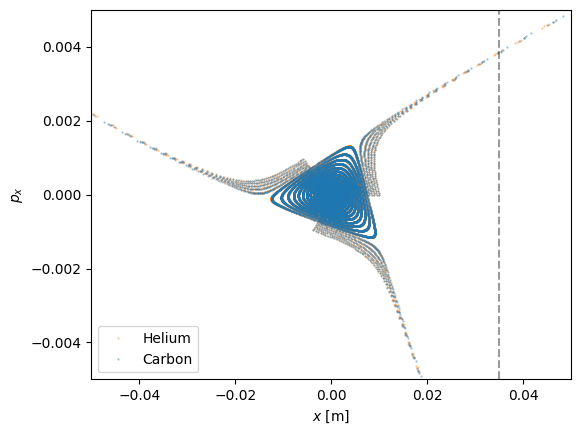

In [76]:
x_septum = 3.5e-2

# Plot turn-by-turn data
plt.figure()
plt.plot(rec_he.x.flatten(), rec_he.px.flatten(), '.', markersize=1, color='C1', alpha=0.5, label='Helium')
plt.plot(rec.x.flatten(), rec.px.flatten(), '.', markersize=1, color='C0', alpha=0.5, label='Carbon')
plt.xlabel(r'$x$ [m]'); plt.ylabel(r'$p_x$'), plt.xlim(-5e-2, 5e-2); plt.ylim(-5e-3, 5e-3)
plt.axvline(x=x_septum, color='k', alpha=0.4, linestyle='--')
plt.subplots_adjust(left=.15)
plt.legend()